# 37 - SGD with Momentum

**Section:** Metaparameters | **Prereqs:** `Metaparameters/BatchNorm.ipynb` | **Next:** `Metaparameters/RMSprop_and_Adam.ipynb`

Plain SGD takes a step in the direction of the current batch's gradient - and
that gradient is noisy, because it came from 16 or 32 samples. Momentum averages
the recent gradients instead:

    v <- beta*v + (1-beta)*grad
    w <- w - lr*v

**The mechanism is an exponentially weighted moving average (EWMA)**, which the
first half of this notebook builds from scratch on a noisy signal. `beta` sets
the memory: roughly the last `1/(1-beta)` gradients count, so beta=0.9 averages
about 10 steps and beta=0.999 about 1000.

**What it buys.** Consistent gradient directions accumulate and the step grows;
noisy ones cancel out. The optimizer rolls through small bumps and dithers less
across narrow valleys - the classic 'ball rolling downhill' picture.

**Values:** 0.9 is the default and almost always right. 0 is plain SGD. 0.999 is
usually too much on a short run - the average is so long that the optimizer keeps
moving in a direction that stopped being correct hundreds of steps ago.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset

# Exponentially Weighted Moving Average

In [ ]:
# A noisy upward-trending signal - a stand-in for the sequence of gradients an
# optimizer actually sees.
noisy_arr = np.array([
  0.03771907,  0.31938554,  0.87991205,  0.99048703,  0.9903557 ,
  1.35847852,  1.64225653,  1.44314128,  0.77666468,  0.37939055,
  0.31301766,  0.2533808 , -0.68529448, -0.22465449, -0.6248298 ,
 -0.46968021, -0.31433421, -0.05390704,  0.43570391,  0.95373702,
  0.9614396 ,  1.76895604,  1.48822685,  2.06447002,  2.42209757,
  2.27820369,  2.02800674,  1.88249938,  1.8504675 ,  1.82507553,
  1.19711454,  1.17823033,  0.96444724,  1.00323668,  0.81334122,
  0.85661181,  0.6527949 ,  1.00209892,  1.54740739,  2.08901235,
  1.62228034,  2.81319413,  3.09154788,  3.19341041,  3.23039321,
  3.15582316,  3.68846272,  3.74709449,  3.52827571,  3.15354812,
  2.60721412,  1.87848742,  2.01087851,  2.03792549,  1.36243504,
  1.86853662,  1.97790259,  2.24979582,  1.95697936,  2.44247223,
  2.86906943,  3.00807642,  4.20959562,  3.81024378,  4.24974741,
  4.17242824,  4.72609838,  4.55512529,  4.17779104,  3.09796403,
  3.51560869,  3.44608886,  3.31340322,  2.65561089,  3.29554689,
  2.35387071,  2.65048508,  3.321498  ,  3.32693113,  4.24170078,
  4.05655576,  4.16905877,  4.5745162 ,  4.63167316,  4.76775247,
  5.43912345,  5.42540626,  5.54738464,  4.76140351,  5.26574923,
  4.41378369,  4.71330549,  3.88237899,  3.62033802,  3.8238791 ,
  4.05943593,  3.89724636,  3.86532436,  3.90984883,  4.22052694
])

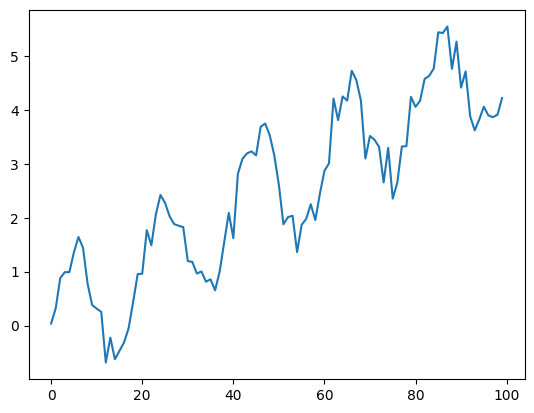

In [ ]:
# The raw signal: a clear trend buried in noise.
plt.plot(noisy_arr);

In [ ]:
# EWMA by hand, one line:  avg[i] = (1-beta)*new + beta*avg[i-1].
# Every past value still contributes, with exponentially decaying weight. Cost:
# one number of state per parameter - which is exactly what momentum stores.
avg = np.zeros(len(noisy_arr))
beta = 0.9
avg[0] = noisy_arr[0]

for i in range(1,len(noisy_arr)):
  avg[i] = (1-beta)*noisy_arr[i]  +  beta*(avg[i-1])

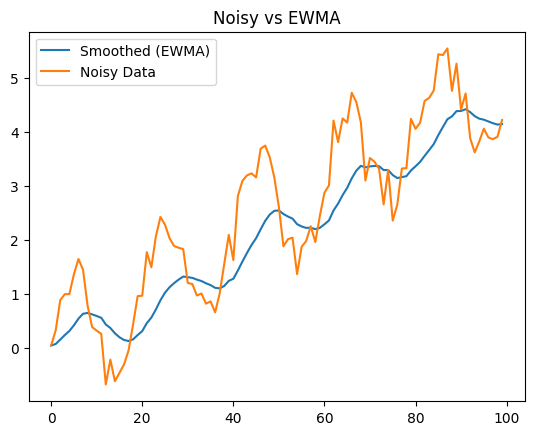

In [ ]:
# Smoothed vs raw. Two things to notice: the noise is largely gone, and the
# smoothed curve LAGS the raw one. That lag is the cost of momentum, and it is
# why very high beta hurts on short runs.
plt.plot(avg, label="Smoothed (EWMA)")
plt.plot(noisy_arr , label="Noisy Data")
plt.legend()
plt.title("Noisy vs EWMA");

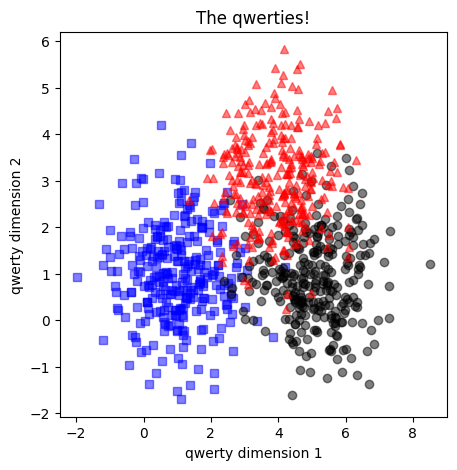

In [ ]:
# Three-cluster qwerties, the standard toy classification problem.
nPerClust = 300
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]
C = [ 4, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.hstack((  np.zeros((nPerClust)),
                         np.ones( (nPerClust)),
                       1+np.ones( (nPerClust))  ))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long() # note: "long" format for CCE

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^',alpha=.5)
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [ ]:
# 90/10 split, batches of 16.
from sklearn.model_selection import train_test_split
train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# finally, translate into dataloader objects
batchsize    = 16
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [ ]:
# Momentum is one optimizer argument: momentum=beta.
# PyTorch's SGD momentum is the classic form (it accumulates the gradient rather
# than the EWMA above), but the behaviour and the intuition are the same.
epochs = 100


def create_model(momentum):
  model = nn.Sequential (
      nn.Linear(2,32),
      nn.ReLU(),
      nn.Linear(32,32),
      nn.ReLU(),
      nn.Linear(32,3)
  )

  lossFunc = nn.CrossEntropyLoss()

  lr =0.01

  optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum) # Beta for Exponetially weight moving average


  return model, lossFunc, optimizer


In [ ]:
# Standard training function taking the momentum value.
def train_model(momentum):

  classifier , lossFunc, optimizer = create_model(momentum)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)

  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []


    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()))

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y).float()))


  return train_acc, test_acc, losses


In [ ]:
# The sweep: beta = 0, 0.5, 0.9, 0.95, 0.999.
beta = [0, 0.5, 0.9, 0.95,0.999]

final_test_acc = []
final_train_acc = []
final_losses = []

for i in beta:
  train ,test, loss = train_model(i)

  final_test_acc.append(test)
  final_train_acc.append(train)
  final_losses.append(loss)

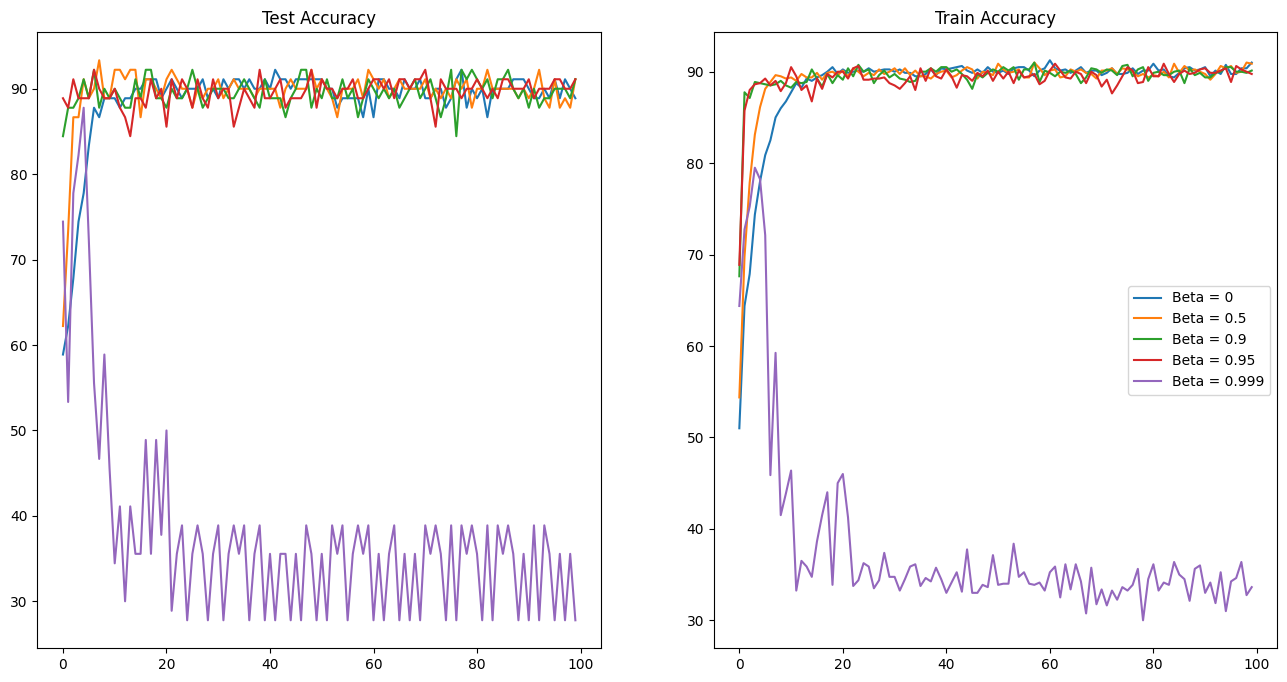

In [ ]:
# Accuracy over epochs for each beta. Higher momentum converges in fewer epochs
# up to a point; beta=0.999 usually oscillates or overshoots, because the
# averaged direction is stale.
fig, ax = plt.subplots(1,2,figsize=(16,8))

for i in range(len(beta)):
  ax[0].plot(final_test_acc[i], label=f"Beta = {beta[i]}")
  ax[1].plot(final_train_acc[i],label=f"Beta = {beta[i]}")

ax[0].set_title("Test Accuracy")
ax[1].set_title("Train Accuracy")
plt.legend();

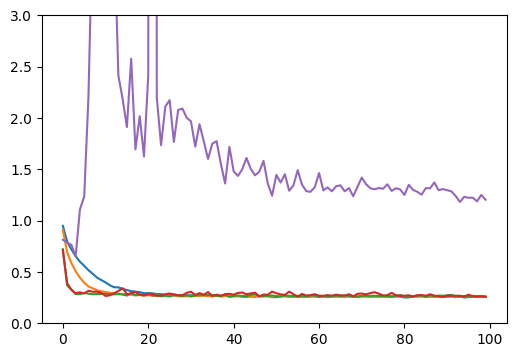

In [ ]:
# Loss curves. beta=0 (plain SGD) is the noisy one; moderate momentum is
# smoother AND faster, which is the reason it is on by default in most recipes.
fig, ax = plt.subplots(figsize=(6,4))
for i in range(len(beta)):
  ax.plot(final_losses[i].detach(), label=f"Beta = {beta[i]}")
  ax.set_ylim([0,3])
